# Day 01. 파이썬 데이터 감각과 NumPy/Matplotlib 복습

## 1) 오늘의 학습 목표

오늘은 AI 모델을 만들기 전에 반드시 필요한 **데이터를 숫자로 보고 다루기**을 복습합니다. 복잡한 이론보다 작은 데이터를 직접 만들고, 계산하고, 그래프로 확인하는 흐름에 집중합니다.

- 리스트와 딕셔너리로 작은 표 데이터를 만들기
- pandas DataFrame에서 행/열을 선택하고 조건으로 데이터를 확인
- NumPy 배열의 `shape`, `axis`, 인덱싱, 브로드캐스팅을 설명
- 평균, 편차, 정규화, 표준화를 직접 계산해보고 차이를 비교
- Matplotlib 그래프로 데이터의 분포, 비교, 관계를 빠르게 확인


AI 모델은 문자, 이미지, 소리처럼 다양한 입력을 결국 **숫자 배열**로 바꾸어 학습합니다. 그래서 데이터가 어떤 모양인지 보고, 필요한 계산을 실수 없이 적용하고, 그래프로 이상한 점을 발견하는 연습이 필요합니다.

오늘 기억할 핵심은 세 가지입니다.

1. **표 데이터**: 행은 보통 한 명의 사람 또는 한 개의 샘플, 열은 특징입니다.
2. **배열 모양**: `shape`는 데이터가 몇 행 몇 열인지 알려줍니다.
3. **축(axis)**: `axis=0`은 열 방향 요약, `axis=1`은 행 방향 요약에 자주 사용합니다.

## 3) 예제: 리스트와 딕셔너리로 표 만들기

먼저 작은 수강생 학습 데이터를 직접 만듭니다. 실제 AI 프로젝트에서도 처음에는 이렇게 표를 보며 데이터의 의미를 확인하는 습관이 중요합니다.


In [1]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no suc

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 그래프에서 한글이 가능한 환경이면 한글 폰트를 자동으로 사용합니다.
korean_font_candidates = ["NanumGothic", "Noto Sans CJK KR", "Noto Sans KR", "Malgun Gothic", "AppleGothic"]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in korean_font_candidates:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break

plt.rcParams["axes.unicode_minus"] = False
# 음수 데이터를 unicode에서 사용할지에 대한 설정
plt.rcParams["figure.figsize"] = (7, 4)

names = ["민지", "도윤", "서연", "지호", "하린", "유찬", "가은", "현우"]
python_scores = [78, 65, 92, 70, 88, 55, 81, 74]
numpy_scores = [72, 68, 95, 73, 84, 60, 79, 77]
study_minutes = [40, 35, 80, 50, 75, 25, 65, 55]
quiz_scores = [70, 66, 96, 74, 86, 58, 82, 76]

students = {
    "name": names,
    "python": python_scores,
    "numpy": numpy_scores,
    "study_minutes": study_minutes,
    "quiz_score": quiz_scores,
}

df = pd.DataFrame(students)
df


,name,python,numpy,study_minutes,quiz_score
0,민지,78,72,40,70
1,도윤,65,68,35,66
2,서연,92,95,80,96
3,지호,70,73,50,74
4,하린,88,84,75,86
5,유찬,55,60,25,58
6,가은,81,79,65,82
7,현우,74,77,55,76


### 표 데이터에서 먼저 확인할 것

데이터를 받으면 바로 모델을 만들기보다 아래 질문부터 확인합니다.

- 행이 몇 개이고 열이 몇 개인가? -> shape 모양이 맞는지 확인
- 각 열은 어떤 의미인가?
- Null 값이 존재하는가?
- 평균이나 최댓값, 최솟값이 예상과 비슷한가?


In [2]:
print("행과 열의 개수:", df.shape)
print("열 이름:", list(df.columns))

# 숫자 열의 요약 통계 확인
df.describe()

행과 열의 개수: (8, 5)
열 이름: ['name', 'python', 'numpy', 'study_minutes', 'quiz_score']


,python,numpy,study_minutes,quiz_score
count,8.000000,8.000000,8.000000,8.000000
mean,75.375000,76.000000,53.125000,76.000000
std,12.117726,10.555973,19.445436,11.952286
min,55.000000,60.000000,25.000000,58.000000
25%,68.750000,71.000000,38.750000,69.000000
50%,76.000000,75.000000,52.500000,75.000000
75%,82.750000,80.250000,67.500000,83.000000
max,92.000000,95.000000,80.000000,96.000000


## 4) 실습 1: pandas로 필요한 정보 뽑기

Pandas는 데이터를 빠르게 확인하고 정리할 때 많이 사용합니다. 오늘은 꼭 필요한 네 가지 작업만 연습합니다.

- 새 열 만들기
- 특정 열만 보기
- 조건에 맞는 행만 보기
- 정렬해서 상위/하위 데이터 확인하기


In [3]:
df["average"] = (df["python"] + df["numpy"] + df["quiz_score"]) / 3
df["needs_review"] = df["average"] < 75
df[["name", "python", "numpy", "quiz_score", "average", "needs_review"]]
# 원하는 열의 순서대로 정렬

df.describe()

,python,numpy,study_minutes,quiz_score,average
count,8.000000,8.000000,8.000000,8.000000,8.000000
mean,75.375000,76.000000,53.125000,76.000000,75.791667
std,12.117726,10.555973,19.445436,11.952286,11.387737
min,55.000000,60.000000,25.000000,58.000000,57.666667
25%,68.750000,71.000000,38.750000,69.000000,70.833333
50%,76.000000,75.000000,52.500000,75.000000,74.500000
75%,82.750000,80.250000,67.500000,83.000000,82.000000
max,92.000000,95.000000,80.000000,96.000000,94.333333


In [4]:
# 평균 점수가 낮은 순서대로 확인합니다.
df_sorted = df.sort_values("average")
# df_sorted = df.sort_values("average", ascending=False)    # 내림차순
df_sorted[["name", "average", "study_minutes", "needs_review"]]


,name,average,study_minutes,needs_review
5,유찬,57.666667,25,True
1,도윤,66.333333,35,True
3,지호,72.333333,50,True
0,민지,73.333333,40,True
7,현우,75.666667,55,False
6,가은,80.666667,65,False
4,하린,86.000000,75,False
2,서연,94.333333,80,False


In [5]:
# 조건 필터링: 복습이 필요한 수강생만 확인합니다.
review_students = df[df["needs_review"]]
review_students[["name", "python", "numpy", "quiz_score", "average"]]


,name,python,numpy,quiz_score,average
0,민지,78,72,70,73.333333
1,도윤,65,68,66,66.333333
3,지호,70,73,74,72.333333
5,유찬,55,60,58,57.666667


`needs_review`는 완벽한 판단 기준이 아닙니다. 실제 교육 현장에서는 출석, 과제, 질문 빈도, 이전 수업 경험 같은 정보도 함께 봐야 합니다. 이러한 간단한 규칙을 코드로 만들어 봅니다.


## 5) 실습 2: NumPy 배열로 계산하기

pandas 표는 보기 편하고, NumPy 배열은 숫자 계산에 강합니다. 점수 열만 뽑아 NumPy 배열로 바꿔봅니다.

In [6]:
score_columns = ["python", "numpy", "quiz_score"]
scores = df[score_columns].to_numpy()

print(scores)
print("배열 모양(shape):", scores.shape)
print("첫 번째 수강생의 점수:", scores[0])
print("Python 점수 열:", scores[:, 0])


[[78 72 70]
 [65 68 66]
 [92 95 96]
 [70 73 74]
 [88 84 86]
 [55 60 58]
 [81 79 82]
 [74 77 76]]
배열 모양(shape): (8, 3)
첫 번째 수강생의 점수: [78 72 70]
Python 점수 열: [78 65 92 70 88 55 81 74]


### axis

`scores`는 8행 3열 배열입니다.

- `axis=0`: 행 방향으로 내려가며 계산하므로 **열마다 하나씩** 결과가 나옵니다.
- `axis=1`: 열 방향으로 옆으로 가며 계산하므로 **행마다 하나씩** 결과가 나옵니다.


In [7]:
subject_means = scores.mean(axis=0)
student_means = scores.mean(axis=1)

print("과목별 평균(axis=0):", subject_means)
print("학생별 평균(axis=1):", student_means)

mean_table = pd.DataFrame({
    "subject": score_columns,
    "mean": subject_means.round(2),
})
mean_table


과목별 평균(axis=0): [75.375 76.    76.   ]
학생별 평균(axis=1): [73.33333333 66.33333333 94.33333333 72.33333333 86.         57.66666667
 80.66666667 75.66666667]


,subject,mean
0,python,75.38
1,numpy,76.00
2,quiz_score,76.00


In [8]:
df["numpy_minus_python"] = df["numpy"] - df["python"]
df["quiz_minus_average"] = df["quiz_score"] - df["average"]

df[["name", "python", "numpy", "numpy_minus_python", "quiz_score", "average", "quiz_minus_average"]]


,name,python,numpy,numpy_minus_python,quiz_score,average,quiz_minus_average
0,민지,78,72,-6,70,73.333333,-3.333333
1,도윤,65,68,3,66,66.333333,-0.333333
2,서연,92,95,3,96,94.333333,1.666667
3,지호,70,73,3,74,72.333333,1.666667
4,하린,88,84,-4,86,86.000000,0.000000
5,유찬,55,60,5,58,57.666667,0.333333
6,가은,81,79,-2,82,80.666667,1.333333
7,현우,74,77,3,76,75.666667,0.333333


### 브로드캐스팅

브로드캐스팅은 작은 배열을 큰 배열 계산에 자동으로 맞춰주는 기능입니다. 예를 들어 과목별 평균을 전체 점수에서 한 번에 빼면, 각 점수가 평균보다 얼마나 높거나 낮은지 알 수 있습니다.


In [9]:
deviation = scores - subject_means

deviation_df = pd.DataFrame(
    deviation.round(2),
    columns=["python_deviation", "numpy_deviation", "quiz_deviation"]
)

pd.concat([df[["name"]], deviation_df], axis=1)


,name,python_deviation,numpy_deviation,quiz_deviation
0,민지,2.62,-4.0,-6.0
1,도윤,-10.38,-8.0,-10.0
2,서연,16.62,19.0,20.0
3,지호,-5.38,-3.0,-2.0
4,하린,12.62,8.0,10.0
5,유찬,-20.38,-16.0,-18.0
6,가은,5.62,3.0,6.0
7,현우,-1.38,1.0,0.0


## 5) 실습 3: 정규화와 표준화 비교

서로 다른 범위의 숫자를 함께 사용할 때는 스케일을 맞추는 과정이 필요합니다.

- **min-max 정규화**: 값을 0~1 범위로 바꿉니다.
- **표준화**: 평균이 0, 표준편차가 1에 가까워지도록 바꿉니다.

In [10]:
min_scores = scores.min(axis=0)
max_scores = scores.max(axis=0)
minmax_scores = (scores - min_scores) / (max_scores - min_scores)
# 이상치가 존재할 경우, 나머지 값들의 차이를 발견하기 어렵다.
# >> 최대값과 최소값이 명확하게 존재해야 한다.

std_scores = (scores - scores.mean(axis=0)) / scores.std(axis=0)

scaled_df = pd.DataFrame({
    "name": df["name"],
    "python": df["python"],
    "python_minmax": minmax_scores[:, 0].round(3),
    "python_standard": std_scores[:, 0].round(3),
})
scaled_df


,name,python,python_minmax,python_standard
0,민지,78,0.622,0.232
1,도윤,65,0.270,-0.915
2,서연,92,1.000,1.467
3,지호,70,0.405,-0.474
4,하린,88,0.892,1.114
5,유찬,55,0.000,-1.798
6,가은,81,0.703,0.496
7,현우,74,0.514,-0.121


In [11]:
print("원본 점수 평균:", scores.mean(axis=0).round(2))
print("min-max 정규화 후 최솟값:", minmax_scores.min(axis=0).round(2))
print("min-max 정규화 후 최댓값:", minmax_scores.max(axis=0).round(2))
print("표준화 후 평균:", std_scores.mean(axis=0).round(2))
print("표준화 후 표준편차:", std_scores.std(axis=0).round(2))


원본 점수 평균: [75.38 76.   76.  ]
min-max 정규화 후 최솟값: [0. 0. 0.]
min-max 정규화 후 최댓값: [1. 1. 1.]
표준화 후 평균: [ 0. -0.  0.]
표준화 후 표준편차: [1. 1. 1.]


## 5) 실습 4: 그래프로 데이터 확인하기

숫자 표만 보면 패턴을 놓치기 쉽습니다. 그래프는 데이터의 비교, 분포, 관계를 빠르게 보여줍니다.


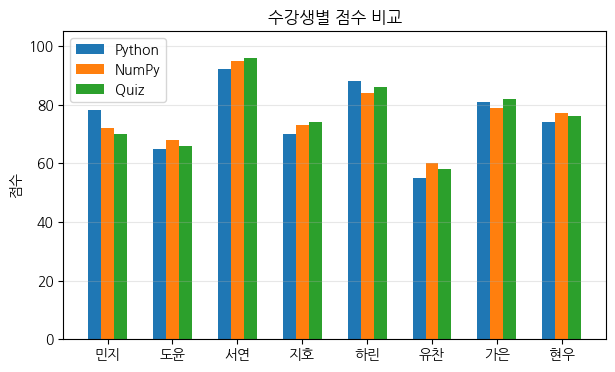

In [12]:
x = np.arange(len(df))

plt.bar(x - 0.2, df["python"], width=0.2, label="Python")
plt.bar(x, df["numpy"], width=0.2, label="NumPy")
plt.bar(x + 0.2, df["quiz_score"], width=0.2, label="Quiz")
# x-0.2 , x+0.2 하는 이유: 너비 0.2로 설정해서, 여러 bar 그래프를 같이 보여주기 위해

plt.xticks(x, df["name"])
plt.ylim(0, 105)
plt.title("수강생별 점수 비교")
plt.ylabel("점수")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()


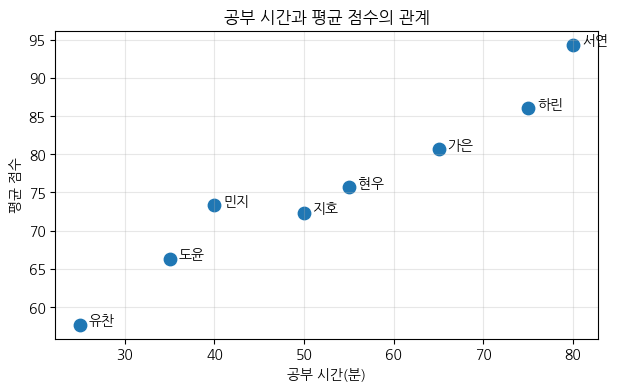

In [13]:
plt.scatter(df["study_minutes"], df["average"], s=80)

for _, row in df.iterrows():
    plt.text(row["study_minutes"] + 1, row["average"], row["name"])

plt.title("공부 시간과 평균 점수의 관계")
plt.xlabel("공부 시간(분)")
plt.ylabel("평균 점수")
plt.grid(True, alpha=0.3)
plt.show()


### 간단한 추세선 그려보기

아직 머신러닝 모델을 본격적으로 만들지는 않지만, “공부 시간이 늘수록 평균 점수가 어떻게 변하는가?”를 직선으로 가볍게 확인할 수 있습니다.


기울기: 0.568
절편: 45.614


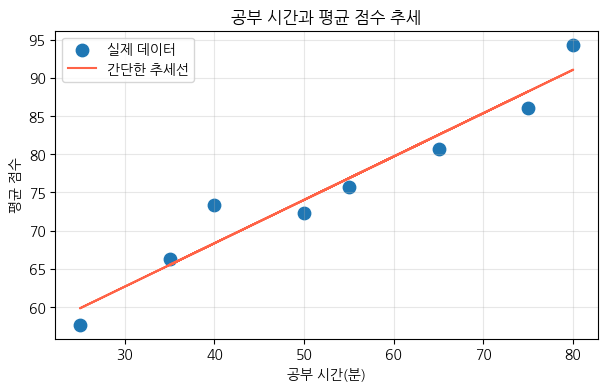

In [14]:
x_data = df["study_minutes"].to_numpy()
y_data = df["average"].to_numpy()

slope, intercept = np.polyfit(x_data, y_data, deg=1)    # polyfit() : 가장 잘 나타내는 1차 함수 그려주는 함수
predicted_line = slope * x_data + intercept

print("기울기:", round(slope, 3))
print("절편:", round(intercept, 3))

plt.scatter(x_data, y_data, s=80, label="실제 데이터")
plt.plot(x_data, predicted_line, color="tomato", label="간단한 추세선")
plt.title("공부 시간과 평균 점수 추세")
plt.xlabel("공부 시간(분)")
plt.ylabel("평균 점수")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


python
numpy
quiz_score


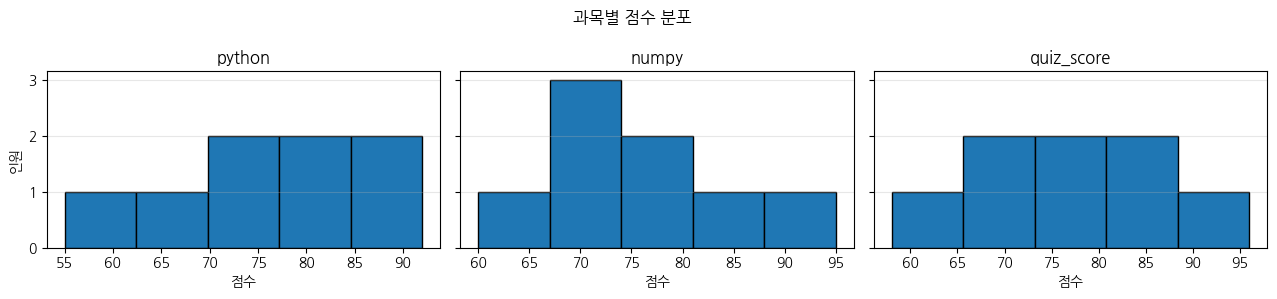

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=True)

for ax, column in zip(axes, score_columns):
    print(column)
    ax.hist(df[column], bins=5, edgecolor="black")
    ax.set_title(column)
    ax.set_xlabel("점수")
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("인원")
plt.suptitle("과목별 점수 분포")
plt.tight_layout()
plt.show()


## 6) 실습 TODO 1: 복습 기준 바꿔보기

아래 셀에서 학생들의 평균이 threshold 보다 낮은지 높은지 나타내는 "needs_review_by_threshold"를 df 데이터 프레임에 추가하세요. 그리고 "name", "average", "needs_review_by_threshold" 순서대로 df 표시하되, "average"를 기준으로 오름차순 정렬하도록 합니다.

`review_threshold` 값을 70, 80, 85 등으로 바꿔보세요. 기준이 바뀌면 복습 대상자가 어떻게 달라지는지 확인합니다.


In [23]:
review_threshold = 75

todo_df = df.copy()

# TO-DO
todo_df['needs_review_by_threshold'] = todo_df['average'] < review_threshold
todo_df_sorted = todo_df.sort_values('average')
todo_df_sorted[['name','average','needs_review_by_threshold']]

,name,average,needs_review_by_threshold
5,유찬,57.666667,True
1,도윤,66.333333,True
3,지호,72.333333,True
0,민지,73.333333,True
7,현우,75.666667,False
6,가은,80.666667,False
4,하린,86.000000,False
2,서연,94.333333,False


## 6) 실습 TODO 2: 새 수강생 추가하기

아래 코드에서 `new_student` 값을 바꿔 새 수강생 한 명을 추가해보세요. 수강생 한 명 추가후, 평균 "average"는 python, numpy, quiz_score를 평균한 점수이며 이를 df_added 데이터프레임에 추가하세요.

점수를 바꾸면 평균과 복습 여부가 자동으로 다시 계산됩니다.




In [26]:
from re import IGNORECASE
# TODO 2: 이름과 점수를 원하는 값으로 수정해보세요.
new_student = {
    "name": "수빈",
    "python": 69,
    "numpy": 71,
    "study_minutes": 45,
    "quiz_score": 73,
}

# TO-DO
df_added = pd.concat([df, pd.DataFrame([new_student])], ignore_index=True)
df_added['average'] = (df_added["python"] + df_added['numpy'] + df_added['quiz_score']) / 3
df_added["needs_review"] = df_added["average"] < review_threshold

df_added[["name", "python", "numpy", "quiz_score", "average", "needs_review"]].tail(3)


,name,python,numpy,quiz_score,average,needs_review
6,가은,81,79,82,80.666667,False
7,현우,74,77,76,75.666667,False
8,수빈,69,71,73,71.000000,True


## 6) 실습 TODO 3: 특정 과목만 분석하기

`selected_subject`를 `"python"`, `"numpy"`, `"quiz_score"` 중 하나로 바꿔보세요. 선택한 과목의 평균, 최솟값, 최댓값과 그래프가 함께 바뀝니다.

먼저 print 문 안의 평균, 최솟값, 최댓값을 나타내는 코드를 작성하세요.


선택한 과목: python
평균: 75.38
최솟값: 55
최댓값: 92


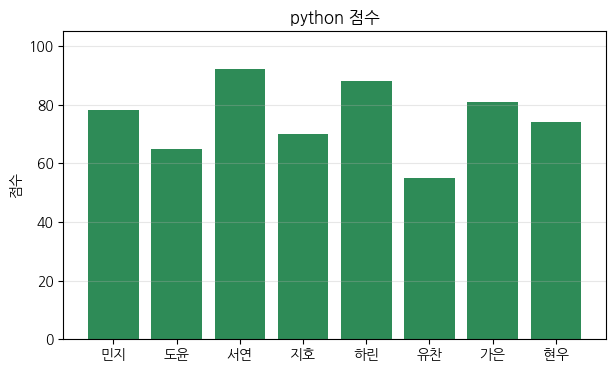

In [31]:
# TODO 3: 아래 값을 "python", "numpy", "quiz_score" 중 하나로 바꿔보세요.
selected_subject = "python"

print("선택한 과목:", selected_subject)
print("평균:", df[selected_subject].mean().round(2)) # 소수 두번째자리까지만 표시하고 반올림
print("최솟값:", df[selected_subject].min())
print("최댓값:", df[selected_subject].max())

plt.bar(df["name"], df[selected_subject], color="seagreen")
plt.ylim(0, 105)
plt.title(f"{selected_subject} 점수")
plt.ylabel("점수")
plt.grid(axis="y", alpha=0.3)
plt.show()


## 6) 실습 TODO 4: 나만의 학습 기록 미니 리포트

아래 `my_study_minutes`와 `my_quiz_score`를 수정해서 나만의 7일 학습 기록을 만들어보세요. 마지막에는 평균 공부 시간, 평균 점수, 가장 점수가 높았던 날을 확인합니다.


평균 공부 시간: 50.0 분
평균 퀴즈 점수: 72.4 점
가장 점수가 높았던 날: 7 일차


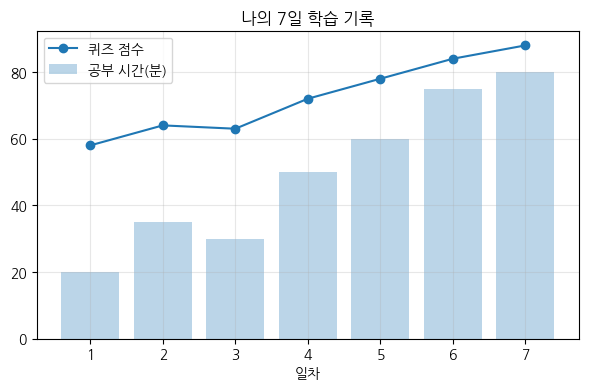

In [19]:
# TODO 4: 숫자를 바꿔 나만의 7일 학습 기록을 만들어보세요.
days = np.arange(1, 8)
my_study_minutes = np.array([20, 35, 30, 50, 60, 75, 80])
my_quiz_score = np.array([58, 64, 63, 72, 78, 84, 88])

best_day_index = my_quiz_score.argmax()

print("평균 공부 시간:", round(my_study_minutes.mean(), 1), "분")
print("평균 퀴즈 점수:", round(my_quiz_score.mean(), 1), "점")
print("가장 점수가 높았던 날:", days[best_day_index], "일차")

plt.plot(days, my_quiz_score, marker="o", label="퀴즈 점수")
plt.bar(days, my_study_minutes, alpha=0.3, label="공부 시간(분)")
plt.xticks(days)
plt.title("나의 7일 학습 기록")
plt.xlabel("일차")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 7) 퀴즈

1. DataFrame에서 `df.shape`는 무엇을 알려주나요?
 - df의 형태
2. `scores.mean(axis=0)`과 `scores.mean(axis=1)`의 열과 개수는 각각 같나요 다르나요? 왜 그럴까요?
- axis=0 : 열 기준 평균 (각 컬럼별 평균) -> 열의 개수만큼 값
- axis=1은 : 행 기준 평균 (각 row별 평균) -> 행의 개수만큼 값

3. 브로드캐스팅을 사용하면 어떤 점이 편리한가요?
- 서로 shape이 다른 배열 간 연산을 루프 없이 벡터화로 처리 가능
- 코드 간결 + 성능 향상
4. min-max 정규화와 표준화는 결과 범위가 어떻게 다른가요? 그리고 이상치가 있을 때 어떤가요?
- min-max는 0과 1 사이에 값이 모든 값이 들어온다.
- 표준화를 하면, 평균 0, 표준편차 1인 값이 들어간다.
- min-max는 이상치에 민감해 범위 압축이 일어난다.
- 표준화는 상대적으로 덜 민감하지만 영향은 있다.
5. 산점도는 어떤 종류의 관계를 확인할 때 유용한가요?
- 상관 관계 분석 시 유리.
- 선형/비선형 관계
- 이상치 탐지
- 군집 패턴 확


## 8) 오늘의 정리

- AI 모델을 만들기 전에는 데이터를 표와 배열로 이해하는 과정이 필요합니다.
- pandas는 데이터를 확인하고 조건으로 걸러볼 때 편리합니다.
- NumPy는 여러 숫자를 한 번에 계산할 때 강력합니다.
- `shape`와 `axis`는 앞으로 텐서, 모델 입력, 이미지 데이터에서도 계속 등장합니다.
- 정규화와 표준화는 숫자 스케일을 맞추는 대표적인 전처리 방법입니다.
- 그래프는 평균, 분포, 관계, 이상치를 빠르게 확인하게 해줍니다.
